# LLM Response Preference Classification

## Overview

The **objective** of this project is to predict which of the two chatbot responses to a user's prompt is preferred. Each sample in the dataset contains a prompt, two responses generated from different chatbots powered by large language models, and the user's preference: response A, response B, or a tie. The dataset used is a collection of conversations from the Chatbot Arena, per the [competition page](https://www.kaggle.com/competitions/llm-classification-finetuning). The log loss is used as the main metric, which scores the predicted probabilities and penalizes confident wrong answers. Accuracy is also provided.

My **approach** was to use a cross-encoder so that the model can compare the responses with the prompt at the same time. The input was generated by concatenating the prompt with the two responses into a single sequence that was fed into the encoder. DeBERTa-v3-xsmall was chosen as the encoder for its small size, its stable training, and results that matched the larger encoders. During training, the order of the responses was swapped at random as data augmentation, to reduce position bias. A custom classifier head with 3 residual blocks was used to predict the probabilities for the three outcomes.

The dataset was split 80/10/10 into training, validation, and held-out test sets. The validation set was used to select the best checkpoint and the test set was used only once during the final evaluation. On the unseen test data, the model achieved a log loss of 1.0191 and 48.76% accuracy, in line with its validation results. As a reference point, predicting the class proportions gives a log loss of 1.097 and 34.9% accuracy.


## Results Summary

|Encoder| Stage | Val loss &darr;| Val acc &uarr; | Test loss &darr;| Test acc &uarr;|
|-|-|-|-|-|-|
|-| Baseline (class proportions)| 1.0972|34.90%|1.0972|34.92%|
|`xsmall`|Cross-encoder, no training |1.8551|30.90%|-|-|
|`xsmall`|Cross-encoder, head only (160 ep, best 49)|1.0748|40.74%|-|-|
|`xsmall`|Cross-encoder, full fine-tuned (20 ep, best 5)|1.0309|46.85%|1.0191|48.76%|
|`small`|Cross-encoder, no training|1.3956|34.20%|-|-|
|`small`|Cross-encoder, head only (160 ep, best 91)|1.0758|40.05%|-|-|
|`small`|Cross-encoder, full fine-tuned (20 ep, best 4)|1.0519|47.63%|1.0367|48.61%|
|`base`|Cross-encoder, no training|1.2848|34.20%|-|-|
|`base`|Cross-encoder, head only (160 ep, best 106)|1.0620|41.58%|-|-|
|`base`|Cross-encoder, full fine-tuned (5 ep, best 4)| 1.0317|48.31%|1.0204|48.76%|

Test columns use the held-out 10% split. *No training* is the pretrained encoder with an untrained head. *Head only* trains just the classifier head. *Full fine-tuned* trains the encoder and the head.

**Note:** The `small` and `base` numbers came from earlier runs and later attempts didn't train reliably. So, `xsmall` is the final model.

## Setup: imports, configuration, and experiment tracking

In [1]:
!pip install -q mlflow
!pip install -q ipywidgets
!pip install -q torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 12.5 MB/s eta 0:00:00


In [2]:
import gc
import os
import sys
import warnings
from functools import partial
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
ON_KAGGLE = os.path.exists("/kaggle/input")
if ON_KAGGLE:
    sys.path.append(
        "/kaggle/input/datasets/fernandoquintinojr/llm-preference-src"
    )

import mlflow
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchinfo
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import AutoConfig, AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging

from models import DeepPreferenceClassifier, PreferenceModel
from plotting import plot_confusion_matrix, plot_results
from preference_datasets import (CrossEncoderDataset, EncodedPreferenceDataset,
                                 collate_cross_encoder)
from text_utils import (format_conversation, parse_conversation, summarize,
                        token_lengths)
from training import (evaluate_performance, set_seed, tracking_start,
                      tracking_stop, train_classifier_model, train_model,
                      validate_epoch)

SEED = 42
generator = set_seed(SEED)
hf_logging.set_verbosity_error()

TARGET_DEVICE = "cuda"

# Options for encoder: "xsmall", "small", "base"
MODEL_SIZE = "xsmall"
TOKENIZER_PRETRAINED = f"microsoft/deberta-v3-{MODEL_SIZE}"
ENCODER_PRETRAINED = f"microsoft/deberta-v3-{MODEL_SIZE}"
HIDDEN_SIZE = AutoConfig.from_pretrained(ENCODER_PRETRAINED).hidden_size

BATCH_SIZE = 128
NUM_WORKERS = 2

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
if device.type != TARGET_DEVICE:
    print(
        f"You are currently using device: {device}. If you plan to train, "
        f"please enable {TARGET_DEVICE}."
    )
else:
    print(f"Device set to {device}")

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

Device set to cuda


In [3]:
if ON_KAGGLE:
    DATA_PATH = "/kaggle/input/competitions/llm-classification-finetuning" # Folder containing data
else:
    DATA_PATH = "data"

classifier_weights_file = f"trained_models/model-classifier-{MODEL_SIZE}-state-dict.pt"
cross_full_model_weights_file = f"trained_models/full-model-{MODEL_SIZE}-state-dict.pt"
encoded_file = f"data/cross-encoded-data-{MODEL_SIZE}.pt"
os.makedirs("trained_models", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [4]:
# SQLite backend (vs. MLflow's older file-store) - must be a genuine local
# path, not cloud-synced storage (e.g. Google Drive), which caused disk I/O
# errors due to SQLite's locking requirements.
mlflow.set_tracking_uri("sqlite:///mlruns_v2")
EXPERIMENT_NAME = "preference-classifier"
if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    mlflow.create_experiment(EXPERIMENT_NAME,
                            artifact_location="mlartifacts")
mlflow.set_experiment(EXPERIMENT_NAME)

2026/10/04 16:41:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/04 16:41:24 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='/kaggle/working/mlartifacts', creation_time=1791132086779, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791132086779, lifecycle_stage='active', name='preference-classifier', tags={}, trace_location=None, workspace='default'>

## The Data

The dataset is loaded from the file `train.csv`. There are 57,477 samples in the dataset containing the following columns: `id`, `model_a`, `model_b`, `prompt`, `response_a`, `response_b`, `winner_model_a`, `winner_model_b`, `winner_tie`. The `winner_*` columns are one-hot encoded and are converted to a single label: 0 = A, 1 = B, 2 = tie. Columns `model_a` and `model_b` contain the names of the chatbots used and are not used as inputs.

The data is split 80/10/10 into training, validation, and test sets. The model is trained on the training set and the validation set is used to select the best checkpoint. The test set is used after training is complete to evaluate the model on unseen data. The split is stratified to preserve the class proportions.


In [5]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
DATA_CLEAN = False
# Convert one-hot winner columns to a single label via argmax:
# 0=response_a, 1=response_b, 2=tie.
labels_one_hot = df[["winner_model_a", "winner_model_b", "winner_tie"]]
labels = labels_one_hot.values.argmax(axis=1)

train_df, val_df, train_labels, val_labels = train_test_split(
    df,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)
val_df, test_df, val_labels, test_labels = train_test_split(
    val_df,
    val_labels,
    test_size=0.5,
    stratify=val_labels,
    random_state=SEED
)

Counting the labels shows that the classes are closely balanced: response_a 34.9%, response_b 34.2%, tie 30.9%.

In [6]:
counts = (np.bincount(labels)/len(labels)) * 100

print(f"Percentage of wins for response_a: {counts[0]:.02f}")
print(f"Percentage of wins for response_b: {counts[1]:.02f}")
print(f"Percentage of ties: {counts[2]:.02f}")

Percentage of wins for response_a: 34.91
Percentage of wins for response_b: 34.19
Percentage of ties: 30.90


The prompt and response columns are stringified lists of conversation turns. They are parsed and joined together with a blank line in order to create more natural text. If a parse fails, the cell is returned as the raw string:

In [7]:
idx = 20
if not DATA_CLEAN:
    print("Text before cleaning:")

    print(train_df["prompt"].iloc[idx])
    print("\nCleaning Data...")
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=SyntaxWarning)
        for col in ["prompt",  "response_a", "response_b"]:
            train_df[col] = train_df[col].apply(parse_conversation).apply(format_conversation)
            val_df[col] = val_df[col].apply(parse_conversation).apply(format_conversation)
            test_df[col] = test_df[col].apply(parse_conversation).apply(format_conversation)
            df[col] = df[col].apply(parse_conversation).apply(format_conversation)
    DATA_CLEAN = True

print("\nText after cleaning:")
print(train_df["prompt"].iloc[idx])

Text before cleaning:
["Name some major events of the 20th century that did not happen in Europe and America","Tell me more about the Chinese Communist Revolution"]

Cleaning Data...

Text after cleaning:
Name some major events of the 20th century that did not happen in Europe and America

Tell me more about the Chinese Communist Revolution


In order for the encoder to see each prompt along with the two responses at the same time, the texts are concatenated into one sequence:

```[CLS] prompt [SEP] response_0 [SEP] response_1 [SEP]```

DeBERTa-v3 was pretrained on sequences of up to 512 tokens, so inputs were truncated to match that. Using DeBERTa's tokenizer, we can get a count for the typical number of tokens for each text:

In [8]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PRETRAINED)

if DATA_CLEAN:
    prompt_lens = token_lengths(train_df["prompt"].tolist(), tokenizer)
    response_a_lens = token_lengths(train_df["response_a"].tolist(), tokenizer)
    response_b_lens = token_lengths(train_df["response_b"].tolist(), tokenizer)

    summarize("prompt", prompt_lens)
    summarize("response_a", response_a_lens)
    summarize("response_b", response_b_lens)
else:
    print("Data has not been cleaned. Please run the cleaning cell above.")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

prompt: mean=80.1, median=20, 95th=316, 99th=1046, max=6584
response_a: mean=289.4, median=227, 95th=798, 99th=1470, max=6377
response_b: mean=291.4, median=229, 95th=790, 99th=1518, max=15670


Truncating response_a and response_b each at 239 and the prompt at 30 keeps at least half of the prompts and half of the responses fully intact (239 + 239 + 30 + 4 = 512). There were 4 special tokens that were reserved: one [CLS] and three [SEP].

## Model Architecture

A cross-encoder model was used so that the encoder could attend to the prompt and both responses at the same time, which helps the classifier head with the judgment. A second reason for selecting a cross-encoder is its simplicity: one encoder pass per sample.

**Input format**
```
prompt = the user's prompt
response_0 = either response_a or response_b
response_1 = the other response_a/b
input = [CLS] prompt [SEP] response_0 [SEP] response_1 [SEP]
```
**Models**
```
model_encoder = DeBERTa v3 (xsmall, small or base)
model_classifier = DeepPreferenceClassifier 3 blocks
model = PreferenceModel (wraps the encoder and classifier)
```
**Pipeline**
```
input -> model -> logits (one score per class)
```
The PreferenceModel class wraps the encoder and classifier as follows:
```
input -> model_encoder -> encoded

encoded -> model_classifier -> logits
```



A few models for the encoder were considered: DeBERTa-v3-small, DeBERTa-v3-base, and DeBERTa-v3-large. Since training was limited to Kaggle's free tier (see Training below), DeBERTa-v3-small was selected at first for its small size. After it was tuned, the encoder was switched to `base`. After `base`, DeBERTa-v3-xsmall was tried. `small` and `base` proved unstable in Stage 2. `xsmall` matched their results and its Stage 2 training proved more reliable. So, `xsmall` became the final encoder. 

`xsmall` has 70,682,112 parameters (including embeddings). The next cell runs a parameter count (including embeddings) on the alternative encoders:

In [9]:
def count_params(model: nn.Module) -> int:
    """
    Returns the number of parameters in the model.

    Args:
        model: The model to count the parameters.
    Returns:
        The number of parameters in the model.
    """
    return sum(param.numel() for param in model.parameters())


print("--Parameter count (including embeddings)--")
for name in ["microsoft/deberta-v3-small", "microsoft/deberta-v3-base", "microsoft/deberta-v3-large"]:
    config = AutoConfig.from_pretrained(name)
    encoder = AutoModel.from_config(config)
    print(f"{name}: {count_params(encoder):,}")

--Parameter count (including embeddings)--


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

microsoft/deberta-v3-small: 141,304,320


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

microsoft/deberta-v3-base: 183,831,552


config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

microsoft/deberta-v3-large: 434,012,160


The classifier head (DeepPreferenceClassifier) receives the final hidden state of the [CLS] token from the encoder. The encoded vector is mapped linearly into a 768-dim hidden size. The vector is then fed into 3 residual blocks (linear, LayerNorm, ReLU, dropout, with a residual connection). The final layer maps to 3 classes. The model's performance declined slightly with more blocks on the validation score (see table below). Validation results for 80-epoch single-seed runs on a Mac:

| Number of Blocks | Val loss &darr;| Val acc &uarr; |
|-|-|-|
| 3 blocks | 1.0704 | 41.09% |
| 6 blocks | 1.0717 | 40.92% |
| 9 blocks | 1.0736 | 40.50% |
| 12 blocks | 1.0743 | 40.45% |
| 15 blocks | 1.0790 | 39.81% |

These experiments ran on a Mac while the numbers in Results Summary came from the Kaggle environment (head-only val loss 1.070 on Mac vs 1.076 on Kaggle). The encoder used for these runs was `small`. Thus, 3 blocks were chosen since it gave us the best validation loss and kept the head small (2.4M parameters for `small` and 2.1M for `xsmall`). 

In [10]:
model_encoder = AutoModel.from_pretrained(
    ENCODER_PRETRAINED,
    dtype=torch.float32
)
model_classifier = DeepPreferenceClassifier(
    input_dim=HIDDEN_SIZE,
    num_blocks=3
)
model = PreferenceModel(model_encoder, model_classifier)
model = model.to(device)

print(f"Encoder parameters: {count_params(model_encoder):,}")
print(f"Classifier parameters: {count_params(model_classifier):,}")
print(f"Total parameters: {count_params(model):,}")

pytorch_model.bin:   0%|          | 0.00/241M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

Encoder parameters: 70,682,112
Classifier parameters: 2,074,371
Total parameters: 72,756,483


The next cell shows the structure of the encoder, the classifier, and the full model.

In [11]:
print("Encoder: " + ENCODER_PRETRAINED)
print(torchinfo.summary(model, depth=3))

Encoder: microsoft/deberta-v3-xsmall
Layer (type:depth-idx)                                            Param #
PreferenceModel                                                   --
├─DebertaV2Model: 1-1                                             --
│    └─DebertaV2Embeddings: 2-1                                   --
│    │    └─Embedding: 3-1                                        49,190,400
│    │    └─LayerNorm: 3-2                                        768
│    │    └─Dropout: 3-3                                          --
│    └─DebertaV2Encoder: 2-2                                      --
│    │    └─ModuleList: 3-4                                       21,293,568
│    │    └─Embedding: 3-5                                        196,608
│    │    └─LayerNorm: 3-6                                        768
├─DeepPreferenceClassifier: 1-2                                   --
│    └─Linear: 2-3                                                295,680
│    └─ReLU: 2-4                 

## Training

The hardware that was used for training was Kaggle's free tier: two T4 GPUs (15 GB each), 12-hour session limit, 30-hour weekly limit. To make the most of this environment, mixed precision, gradient checkpointing and DataParallel (for training) were used. Additionally, training was broken down into three stages. In Stage 0, the input was encoded once and cached. In Stage 1, the classifier was trained with the embedding cache for 160 epochs. In Stage 2, the full model was fine-tuned for 20 epochs for DeBERTa-v3-xsmall and DeBERTa-v3-small (with best at epoch 5 and 4, respectively). For DeBERTa-v3-base, the model was trained for 5 epochs with best at epoch 4.

Training the classifier separately with an embedding cache was inexpensive compared to the full training (or even just freezing the encoder) and allowed the classifier to start Stage 2 with trained weights instead of random weights. Stage 1 for the `base` encoder took 12.3 min for 160 epochs while Stage 2 took 157 min for 5 epochs. Additionally, splitting the training allowed for cheap experimentation when determining the number of blocks to include in the classifier. The same embedding cache was used for 3-blocks, 6-blocks, 9-blocks, 12-blocks, and 15-blocks (each with 80 epochs) on a Mac.

The following table records PyTorch's peak allocated memory (from single runs) and time for each stage.

|Stage|`xsmall` time|`xsmall` peak memory (GPU 0 / GPU 1)|`small` time | `small` peak memory (GPU 0 / GPU 1) | `base` time | `base` peak memory (GPU 0 / GPU 1) |
|-|-|-|-|-|-|-| 
|Stage 0: Embedding cache|9.8 min|2.55 GB / 0.00 GB|9.9 min|4.35 GB / 0.00 GB|19.1 min|5.38 GB / 0.00 GB|
|Stage 1: Head only|11.0 min|0.66 GB / 0.04 GB|11.0 min|1.16 GB / 0.04 GB|12.3 min|1.50 GB / 0.04 GB|
|Stage 2: full fine-tuned |312.0 min (20 epochs)|4.30 GB / 3.20 GB|328.7 min (20 epochs)|7.76 GB / 5.61 GB|157.0 min (5 epochs)|9.05 GB / 6.39 GB| 


### Validation before training
The untrained model (loss 1.8551 and accuracy 30.90%) scores worse than guessing the class proportions (loss 1.0972 and accuracy 34.90%) on the validation set:

In [12]:
print("--Validation before training--")
val_dataset = CrossEncoderDataset(
    prompts=val_df["prompt"].tolist(),
    responses_a=val_df["response_a"].tolist(),
    responses_b=val_df["response_b"].tolist(),
    labels=val_labels,
    tokenizer=tokenizer,
    prob=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()

if device.type == TARGET_DEVICE:
    loss = nn.CrossEntropyLoss()
    model = model.to(device)
    epoch_loss, epoch_acc = validate_epoch(model, val_loader, device, loss)
    print(f"Validation loss: {epoch_loss}")
    print(f"Validation acc: {epoch_acc}")
else:
    print(
        f"Device is set to {device}. Needs to be set to {TARGET_DEVICE}."
    )

--Validation before training--
Validation loss: 1.8551218430864869
Validation acc: 30.89770354906054


### Stage 0: Build the embedding cache

Stage 0 passes the inputs through the encoder once and saves them in a file to be used in Stage 1. A custom dataset (`CrossEncoderDataset`) is used for the embedding (also used in Stage 2 for the full fine-tuning). The dataset takes a sample's texts (`prompt`, `response_0`, `response_1`) and concatenates them into a single input after truncating the texts and swapping `response_0` and `response_1` with the given probability (prob). For the embedding cache (and hence for Stage 1) the probability is set to prob=0. The dataset returns each input at its natural length up to 512. Thus, a custom collate function (`collate_cross_encoder`) is used to pad each batch to the length of its longest sample.

The next cell creates the dataset and the data loader for building the embedding cache.

In [13]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PRETRAINED)

if DATA_CLEAN:
    full_dataset = CrossEncoderDataset(
        prompts=df["prompt"].tolist(),
        responses_a=df["response_a"].tolist(),
        responses_b=df["response_b"].tolist(),
        labels=labels,
        tokenizer=tokenizer,
        prob=0
    )
    full_loader = DataLoader(
        full_dataset,
        batch_size=64,
        shuffle=False,
        collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
        num_workers=NUM_WORKERS,
    )
else:
    raise RuntimeError(
        "Data has not been cleaned. Please run the cleaning cell in The Data "
        "section."
    )

The next cell builds the embedding cache file.

In [14]:
# Preprocess input through encoder:
start_time = tracking_start()
print("\n--Encoding the input for fast classifier training--")
print(f"Encoding using device: {device}")
model_encoder = AutoModel.from_pretrained(
    ENCODER_PRETRAINED,
    dtype=torch.float32,
)
model_encoder = model_encoder.to(device)
model_encoder.eval()

num_samples = len(full_dataset)
encoded = torch.zeros(num_samples, HIDDEN_SIZE)
dataset_idx =torch.zeros(num_samples, dtype=torch.long)

with torch.no_grad():
    for batch in tqdm(full_loader):
        idx = batch["idx"]
        batch = {k: v.to(device) for k,v in batch.items() if k != "idx"}
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            output = model_encoder(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            ).last_hidden_state[:,0,:]
        encoded[idx] = output.float().cpu()
        dataset_idx[idx] =idx.cpu()

print("Saving...")
encoded_file = f"cross-encoded-data-{MODEL_SIZE}.pt"
torch.save(
    {"encoded": encoded, "label": torch.tensor(labels), "idx": dataset_idx},
    encoded_file
)

print("Saved file")
tracking_stop(start_time)


--Encoding the input for fast classifier training--
Encoding using device: cuda


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

100%|██████████| 899/899 [09:48<00:00,  1.53it/s]


Saving...
Saved file
Duration of Execution: 9.8 minutes
GPU 0 peak memory: 2.55 GB
GPU 1 peak memory: 0.00 GB


### Stage 1: Pretrain the classifier head

In Stage 1, the classifier is trained. The embeddings are cached and a custom dataset (`EncodedPreferenceDataset`) is used to handle the pooled encoded input (`prompt/response_0/response_1`) and the `label`. Since the input has been pre-encoded in Stage 0, training the head is inexpensive. Thus, the head is trained for 160 epochs and the epoch with the best validation score is kept. The best epoch for `xsmall` is 49 (epoch 91 for `small` and epoch 106 for `base`). In all cases, the training plateaus. The following graph shows the training for `xsmall` (the graph for the other encoders is similar):

<img src="images/loss_history_classifier_cross.png" height="220">
<img src="images/acc_history_classifier_cross.png" height="220">

The graphs show that the classifier plateaus but does not overfit even with many epochs. 

The following cell takes the embedding cache and creates the custom dataset (`EncodedPreferenceDataset`):

In [15]:
print("--Caching embedding--")
cache = torch.load(encoded_file)
encoded, labels_cached = cache["encoded"], cache["label"]

train_encoded_dataset = EncodedPreferenceDataset(
    encoded=encoded,
    labels=labels_cached,
    indices=train_df.index.values
)
val_encoded_dataset = EncodedPreferenceDataset(
    encoded=encoded,
    labels=labels_cached,
    indices=val_df.index.values,
)

--Caching embedding--


This is where we train the classifier head only.

Run Name: Cross-Encoder-classifier_xsmall-3-blocks
Training on device cuda for 160 epochs:


Epoch 160 | Train loss: 1.0686 acc: 41.18% | Val loss: 1.0752 acc: 40.76%: 100%|██████████| 160/160 [10:57<00:00,  4.11s/it]


Training Complete.
Best Val loss: 1.0748192134962036
Val Acc: 40.7446068197634
Best epoch: 49

Saved model as: model-classifier-xsmall-state-dict.pt



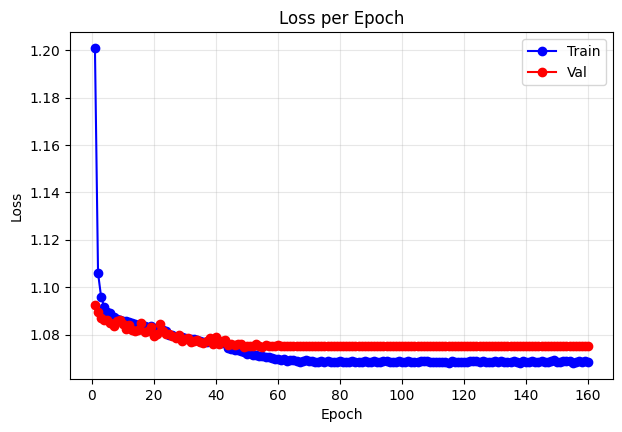

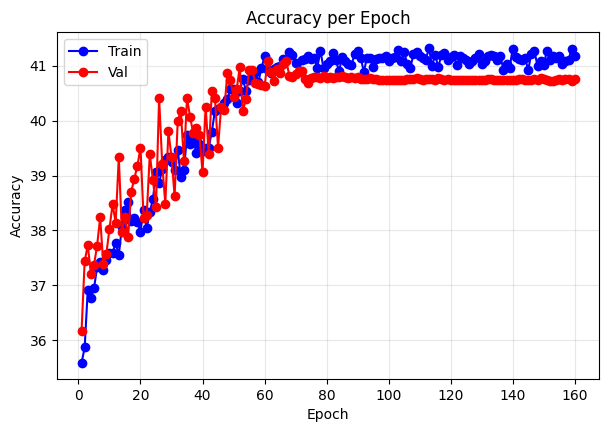

Duration of Execution: 11.0 minutes
GPU 0 peak memory: 0.66 GB
GPU 1 peak memory: 0.04 GB


In [16]:
block = 3

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()
run_name = (
    f"Cross-Encoder-classifier_{MODEL_SIZE}-{block}-"
    "blocks"
)

print("Run Name: " + run_name)
start_time = tracking_start()
generator = set_seed(SEED)
train_encoded_loader = DataLoader(
    train_encoded_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Pre-encoded data. Workers will add overhead.
    generator=generator,
)
val_encoded_loader = DataLoader(
    val_encoded_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Pre-encoded data. Workers will add overhead.
    generator=generator,
)

model_classifier = DeepPreferenceClassifier(
    input_dim=HIDDEN_SIZE,
    num_blocks=block
)
scaler = torch.amp.GradScaler(device.type)
loss = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = optim.AdamW(model_classifier.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",  # Decrease val loss.
    factor=0.5,
    patience=3,
)

# Confirm the runtime actually has the intended device before running
# training.
if device.type == TARGET_DEVICE:
    results = train_classifier_model(model=model_classifier,
                        train_loader=train_encoded_loader,
                        val_loader=val_encoded_loader,
                        device=device,
                        optimizer=optimizer,
                        loss=loss,
                        num_epochs=160,
                        scaler=scaler,
                        scheduler=scheduler,
                        run_name=run_name
    )

    classifier_weights_file = f"model-classifier-{MODEL_SIZE}-state-dict.pt"
    torch.save(results["best_model"].state_dict(), classifier_weights_file)
    print(f"\nSaved model as: {classifier_weights_file}\n")

    plot_results(results)
else:
    print(
        f"Device is set to {device} (Needs to be set to {TARGET_DEVICE})."
        )

tracking_stop(start_time)

### Stage 2: Full fine-tuning

At this point in the training, neither the encoder nor the classifier has random weights but they have been trained independently. The final stage is to fine-tune the full model (both the head and the encoder at the same time). We use a custom model (`PreferenceModel`) that wraps both the encoder and the classifier to create a full end-to-end model.

We use the custom dataset from Stage 0 (`CrossEncoderDataset`) without setting prob=0 for the training set. The default permutes the responses (response_a and response_b) with probability 0.5 as data augmentation. We keep prob=0 for both the validation set and the test set.

This is the most expensive stage in the training. One epoch takes about 15.6 min for `xsmall` (16 min for `small` and 31 min for `base`) with peak allocated memory (GPU 0 / GPU 1) at 4.30 GB / 3.20 GB for `xsmall` (7.76 GB / 5.61 GB for `small` and 9.05 GB / 6.39 GB for `base`). With all encoders the model reaches its best score within 5 epochs. The encoders `small` and `base` produced accuracy of about 48% in Stage 2. However, these results were not reproducible. Stage 1 was stable for all encoders resulting in differences within one percentage point even when given different random weights. Tiny differences in training the head (for `small` and `base`) in Stage 1 determined whether the full model trained well or degenerated in Stage 2 (even though the heads' metrics were almost the same). Learning-rate warmup (first 180 steps) and gradient clipping (max norm 1.0) were added to improve the stability of Stage 2. In a run with `small`, this helped the validation accuracy escape its plateau, but the log loss did not improve by much. In the end, `xsmall` proved stable in all stages.

The encoder `xsmall` was trained for 20 epochs. After reaching its best loss score, it began to overfit the data:

<img src="images/loss_history_full_model_cross.png" height="250">
<img src="images/acc_history_full_model_cross.png" height="250">

The next cell loads the weights for the pre-trained encoder and classifier. The two models are then wrapped with `PreferenceModel`:

In [17]:
model_encoder = AutoModel.from_pretrained(ENCODER_PRETRAINED, dtype=torch.float32)
model_encoder.gradient_checkpointing_enable()
model_classifier = DeepPreferenceClassifier(input_dim=HIDDEN_SIZE, num_blocks=3)
model_classifier.load_state_dict(torch.load(classifier_weights_file, map_location="cpu"))
model = PreferenceModel(model_encoder,model_classifier)
model = model.to(device)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

The next cell uses the custom dataset (`CrossEncoderDataset`) to create the train set and val set. 

In [18]:
if DATA_CLEAN:
    train_dataset = CrossEncoderDataset(
        prompts=train_df["prompt"].tolist(),
        responses_a=train_df["response_a"].tolist(),
        responses_b=train_df["response_b"].tolist(),
        labels=train_labels,
        tokenizer=tokenizer,
    )
    val_dataset = CrossEncoderDataset(
        prompts=val_df["prompt"].tolist(),
        responses_a=val_df["response_a"].tolist(),
        responses_b=val_df["response_b"].tolist(),
        labels=val_labels,
        tokenizer=tokenizer,
        prob=0,
    )
else:
    raise RuntimeError(
        "Data has not been cleaned. Please run the cleaning cell in The Data "
        "section."
    )

After resetting the generator, DataLoaders are created for each set and pass along the custom collate function (see Stage 0).

In [19]:
generator = set_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)

The next cell runs the most expensive training, the full fine-tuning. This run used 20 epochs and the best epoch was 5. After 5 epochs, the model begins to overfit. On average, each epoch takes 15.6 min to run.

Run name: full-fine-tuning-xsmall
Training on device cuda for 20 epochs:


Epoch 20 | Train loss: 0.6988 acc: 67.16% | Val loss: 1.4637 acc: 44.57%: 100%|██████████| 20/20 [5:12:00<00:00, 936.05s/it]


Training Complete.
Best Val loss: 1.0308995772005372
Val Acc: 46.85107863604732
Best epoch: 5

Saved model as: full-model-xsmall-state-dict.pt



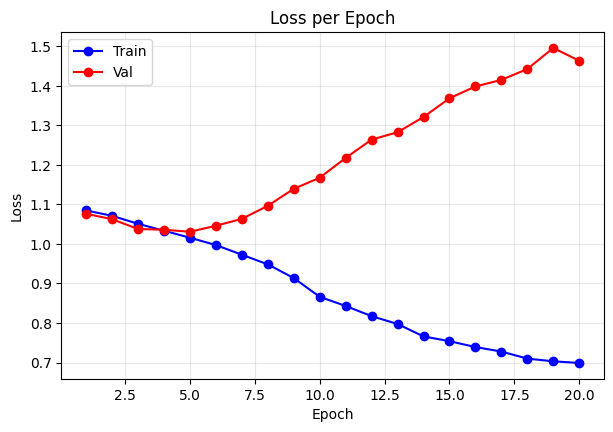

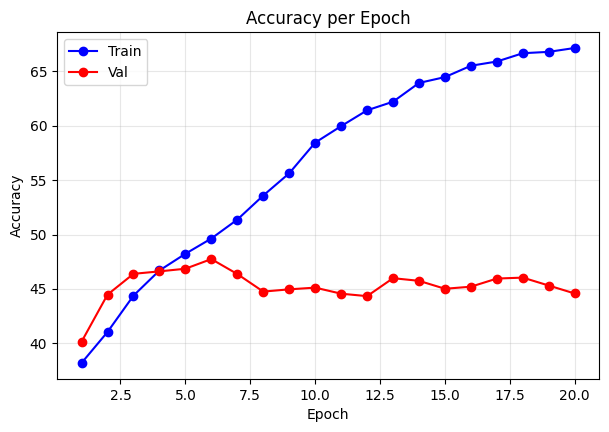

Duration of Execution: 312.0 minutes
GPU 0 peak memory: 4.30 GB
GPU 1 peak memory: 3.20 GB


In [20]:
run_name = f"full-fine-tuning-{MODEL_SIZE}"
print("Run name: " + run_name)
start_time = tracking_start()
gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()

scaler = torch.amp.GradScaler(device.type)
loss = nn.CrossEntropyLoss()
learning_rate = 2e-5
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",  # Decrease val loss.
    factor=0.5,
    patience=3,
)

# Confirm the runtime actually has the intended device before running training.
if device.type == TARGET_DEVICE:
    results = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        optimizer=optimizer,
        loss=loss,
        num_epochs=20,
        scaler=scaler,
        scheduler=scheduler,
        run_name=run_name,
        abort_epoch=None,
        max_grad_norm=1.0,
        warmup_steps=180,
    )

    cross_full_model_weights_file = f"full-model-{MODEL_SIZE}-state-dict.pt"
    torch.save(
        results["best_model"].state_dict(),
        cross_full_model_weights_file
    )
    print(f"\nSaved model as: {cross_full_model_weights_file}\n")

    plot_results(results)
else:
    print(f"Device is set to {device} (Needs to be set to {TARGET_DEVICE}).")
tracking_stop(start_time)

The final step is to see how the model performs on data it has not seen before.

In [21]:
if DATA_CLEAN:
    test_dataset = CrossEncoderDataset(
        prompts=test_df["prompt"].tolist(),
        responses_a=test_df["response_a"].tolist(),
        responses_b=test_df["response_b"].tolist(),
        labels=test_labels,
        tokenizer=tokenizer,
        prob=0,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
        generator=generator,
    )
else:
    raise RuntimeError(
        "Data has not been cleaned. Please run the cleaning cell in The Data "
        "section."
    )

We load the trained model and evaluate its performance on the test set:

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

100%|██████████| 45/45 [01:00<00:00,  1.34s/it]


Test loss: 1.019103235640954
Test acc: 48.764787752261654



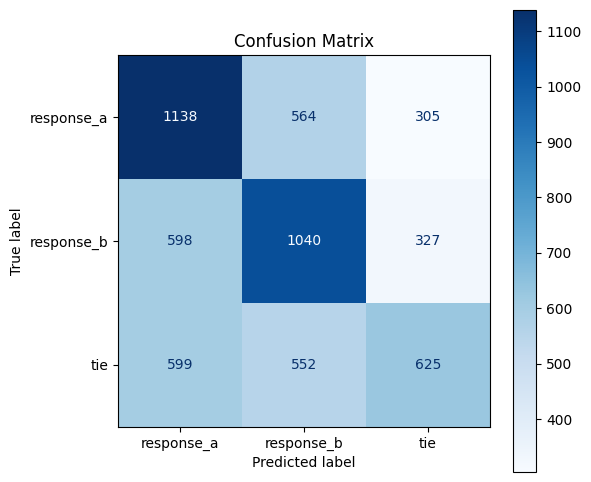

Duration of Execution: 1.0 minutes
GPU 0 peak memory: 5.57 GB
GPU 1 peak memory: 0.02 GB


In [22]:
model_encoder = AutoModel.from_pretrained(ENCODER_PRETRAINED, dtype=torch.float32)
model_classifier = DeepPreferenceClassifier(input_dim=HIDDEN_SIZE, num_blocks=3)
model = PreferenceModel(model_encoder,model_classifier)
model.load_state_dict(torch.load(cross_full_model_weights_file, map_location="cpu"))
model = model.to(device)

start_time = tracking_start()
gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()

loss = nn.CrossEntropyLoss()
if device.type == TARGET_DEVICE:
    all_labels, all_preds, epoch_loss, epoch_acc = evaluate_performance(
        model=model,
        loader=test_loader,
        device=device,
        loss=loss,
    )
    print(f"Test loss: {epoch_loss}")
    print(f"Test acc: {epoch_acc}\n")
    plot_confusion_matrix(
        all_labels=all_labels,
        all_preds=all_preds,
        display_labels=["response_a", "response_b", "tie"],
    )
else:
    print(f"Device {device} does not match target device {TARGET_DEVICE}.")
tracking_stop(start_time)

## Conclusion
DeBERTa-v3-xsmall remained consistent across the validation (log loss of 1.031, accuracy of 46.9%) and test (log loss 1.019, accuracy of 48.8%) datasets. The log loss is the main metric that is used because it penalizes confident wrong answers. As a point of reference, guessing the class proportions on the test set gives a log loss of 1.0972 and accuracy of 34.92%.

The confusion matrix shows where the model needs to improve. The model learned to correctly identify only 35.2% of true ties (compare with 56.7% for Response A and 52.9% for Response B). When the model did predict ties, 49.7% of the samples were correct (compare with 48.7% for Response A and 48.2% for Response B).